## Import Libraries



In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

## Load Data

In [19]:
delay_df = pd.read_csv("Delay_Category_Summary.csv")
delivery_person_df = pd.read_csv("Delivery_Person_Summary.csv")
delivery_df = pd.read_csv("Delivery_Summery.csv")
fulfillment_df = pd.read_csv("Fulfillment_Summary.csv")

## Delay Category Analysis

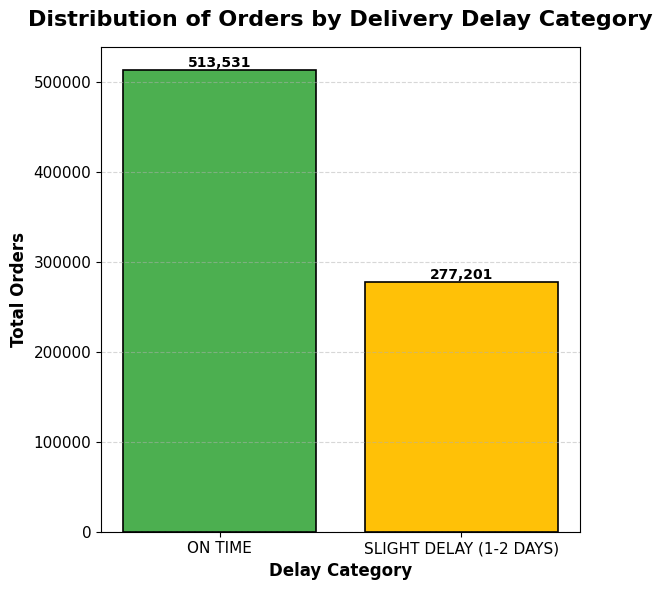

In [20]:
plt.figure(figsize=(6, 6))

bars = plt.bar(
    delay_df["DELIVERY_DELAY_CATEGORY"],
    delay_df["TOTAL_ORDERS"],
    color=["#4CAF50", "#FFC107", "#FF7043", "#D32F2F"],
    edgecolor="black",
    linewidth=1.2
)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "Distribution of Orders by Delivery Delay Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Delay Category", fontsize=12, fontweight="bold")
plt.ylabel("Total Orders", fontsize=12, fontweight="bold")

plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Delivery Person Analysis
Top 10 delivery persons:


In [21]:
top10 = delivery_person_df.sort_values(
    by="TOTAL_DELIVERIES",
    ascending=False
).head(10)

top10

,DELIVERY_PERSON_NAME,EMPLOYMENT_TYPE,VEHICLE_TYPE,TOTAL_DELIVERIES,AVG_DELAY,AVG_RATING,ON_TIME_RATE
118,Madhup Dara,FULL-TIME,BIKE,327,0.44,3.99,65.14
1889,Saira Bhavsar,FULL-TIME,BIKE,239,0.46,3.98,63.18
1980,Lagan Bala,FULL-TIME,EV BIKE,234,0.47,3.96,61.97
6833,Misha Bora,FULL-TIME,BIKE,230,0.42,4.09,65.65
4726,Anika Maharaj,CONTRACT,VAN,229,0.52,3.91,60.26
5828,Madhav Bhandari,CONTRACT,BIKE,227,0.49,3.96,59.91
2834,Zara Vasa,FULL-TIME,VAN,227,0.53,3.88,62.11
5168,Anya Kanda,FULL-TIME,VAN,227,0.44,4.04,66.08
6708,Anvi Chandran,FULL-TIME,EV BIKE,224,0.45,4.00,64.73
1193,Navya Bora,FULL-TIME,VAN,224,0.42,4.03,66.52


Average rating by vehicle:

In [24]:
delivery_person_df.groupby(
    "VEHICLE_TYPE"
)["AVG_RATING"].mean().round(2)

,AVG_RATING
VEHICLE_TYPE,
BIKE,4.0
EV BIKE,4.0
SCOOTER,4.0
VAN,4.0


On-time rate by employment type:

In [25]:
delivery_person_df.groupby(
    "EMPLOYMENT_TYPE"
)["ON_TIME_RATE"].mean()

,ON_TIME_RATE
EMPLOYMENT_TYPE,
CONTRACT,64.963057
FULL-TIME,64.910019


## Fulfillment Analysis
Orders by shipping method:

In [30]:
fulfillment_df.groupby(
    "SHIPPING_METHOD"
)["TOTAL_ORDERS"].sum()

,TOTAL_ORDERS
SHIPPING_METHOD,
EXPRESS,263854
SAME DAY,263976
STANDARD,262902


Orders by service level:

In [31]:
fulfillment_df.groupby(
    "SERVICE_LEVEL"
)["TOTAL_ORDERS"].sum()

,TOTAL_ORDERS
SERVICE_LEVEL,
ECONOMY,262902
PREMIUM,263976
PRIORITY,263854


Average delay by shipping method:

In [33]:
fulfillment_df.groupby(
    "SHIPPING_METHOD"
)["AVG_DELAY"].mean()*100

,AVG_DELAY
SHIPPING_METHOD,
EXPRESS,45.0
SAME DAY,45.0
STANDARD,45.0


On-time rate comparison:

In [34]:
fulfillment_df.groupby(
    "SERVICE_LEVEL"
)["ON_TIME_RATE"].mean()

,ON_TIME_RATE
SERVICE_LEVEL,
ECONOMY,65.02
PREMIUM,64.76
PRIORITY,65.05


## Key Business Insights

In [40]:
print("Highest On-Time Rate:")

delivery_person_df.sort_values(
        by="ON_TIME_RATE",
        ascending=False
)[['DELIVERY_PERSON_NAME','ON_TIME_RATE']].head(10)

Highest On-Time Rate:


,DELIVERY_PERSON_NAME,ON_TIME_RATE
6920,Tarini Singhal,83.04
3812,Amani Saraf,80.34
2883,Pari Swamy,80.20
2117,Mohanlal Kulkarni,79.82
3136,Siya Sheth,79.79
6978,Neelofar Mander,79.76
934,Neysa Raja,79.52
6645,Mohanlal Sundaram,79.38
5888,Kismat Sarin,79.31
5876,Pihu Sridhar,79.21


In [42]:
print("Highest Delay Days:")

delivery_df.sort_values(
        by="AVG_DELAY",
        ascending=False
    ).head(10)

Highest Delay Days:


,ORDER_DATE,TOTAL_ORDERS,AVG_DELAY,AVG_RATING,ON_TIME_RATE,DELAY_RATE
347,2025-10-24,2202,0.49,3.96,62.67,37.33
365,2026-04-01,2150,0.48,3.98,63.40,36.60
232,2025-04-16,2132,0.48,3.95,63.09,36.91
13,2025-07-21,2206,0.48,3.96,62.83,37.17
200,2025-08-26,2108,0.48,3.97,63.05,36.95
92,2025-04-21,2152,0.48,3.97,63.57,36.43
313,2025-12-15,2158,0.48,3.97,62.60,37.40
231,2025-04-05,2156,0.48,3.96,63.22,36.78
36,2025-11-21,2115,0.48,3.98,63.22,36.78
205,2025-10-04,2215,0.48,3.95,63.39,36.61
